# Simulation Convergence Study

This notebook serves to prove that the simulation converges with simulation parameters. It also provides a convenient space for users to check if their design is converged with a simple edit of the design and materials.

In [4]:
import Pkg
Pkg.activate(joinpath(@__DIR__, ".."))
Pkg.instantiate()

using BullseyeFDFD
using Printf, CSV, DataFrames

  Activating project at `~/BullseyeFDFD/BullseyeFDFD/validation`


## Baseline design & materials

Users can edit this cell for their own designs or to check for convergence of an optimized design.

In [5]:
nClad = 1.00
nSiN  = 2.01066
nSiO2 = 1.45375
nSi   = 3.69476 - 1im*0.00482

tCBG  = 0.17886
tSiO2 = 0.75057

λ  = 0.780
NA = 0.4

substrates = [(n = nSiO2, height = tSiO2),
              (n = nSi,   height = Inf)]

design = [0.355000,             # eye
          0.100000, 0.370000,   # trench 1, ring 1
          0.100000, 0.370000,   # trench 2, ring 2
          0.100000, 0.370000,   # trench 3, ring 3
          0.100000, 0.370000,   # trench 4, ring 4
          0.100000, 0.370000,   # trench 5, ring 5
          0.100000, 0.370000,   # trench 6, ring 6
          0.100000, 0.370000,   # trench 7, ring 7
          0.100000, 0.370000,   # trench 8, ring 8
          0.100000, 0.370000,   # trench 9, ring 9
          0.100000, 0.370000,   # trench 10, ring 10
          0.100000]             # buffer

geometry = build_geometry(design, substrates, nClad, nSiN, tCBG)

resultsdir = joinpath(@__DIR__, "results")
mkpath(resultsdir);

## Sweep machinery

`eval_point()` collects all the simulation parameters for verification of convergence and gathers simulation time and ram allocated by Julia.

`run_sweep()` sweeps a parameter value and records its result in a `DataFrame()`.

`save()` saves the data in a CSV file.

In [3]:
function eval_point(; λPts=20, geoPts=16,
                    PMLρ=0.5, PMLz=0.5, padρ=0.5, padz=0.5,
                    R_target=1e-12)

    grid = conformal_grid(geometry, λ;
                          λPts, geoPts,
                          PMLρ, PMLz_bot=PMLz, PMLz_top=PMLz,
                          padρ, padz_bot=padz, padz_top=padz)
    ϵ = build_epsilon(geometry, grid)

    eig = @timed solve_sim(grid, ϵ, λ, NA; Nmodes=1, report=false, plots=false, R_target)
    m = eig.value.modes[1]

    src = dipole(grid, m.λ)
    drv = @timed solve_sim(grid, ϵ, λ; source=src, report=false, plots=false, R_target)
    P = drv.value.driven.Purcell

    GC.gc()
    return (λ_nm = m.λ*1000, Q = m.Q, V = m.V_eff, Fp = m.Fp, CF = m.CF,
            η = m.η, gaussicity = m.gaussicity, Purcell = P,
            Nρ = grid.Nρ, Nz = grid.Nz,
            eig_s = eig.time, eig_GB = eig.bytes/1024^3,
            drv_s = drv.time, drv_GB = drv.bytes/1024^3)

end;

function run_sweep(param::Symbol, values; base...)
    df = DataFrame()
    println("── sweeping $param ──")
    for v in values
        kw = Dict{Symbol,Any}(base)
        kw[param] = v
        r = eval_point(; kw...)
        @printf("  %s=%-7s → λ=%.2f Q=%.0f V=%.3f Fp=%.1f P=%.1f η=%.3f CF=%.3f G=%.3f  %d×%d  eig %.1fs/%.1fGB  drv %.1fs/%.1fGB\n",
        param, string(v), r.λ_nm, r.Q, r.V, r.Fp, r.Purcell, r.η, r.CF, r.gaussicity,
        r.Nρ, r.Nz, r.eig_s, r.eig_GB, r.drv_s, r.drv_GB)
        push!(df, (sweep=String(param), value=float(v),
                   λ_nm=r.λ_nm, Q=r.Q, V=r.V, Fp=r.Fp, Purcell=r.Purcell, CF=r.CF,
                   η=r.η, gaussicity=r.gaussicity, Nρ=r.Nρ, Nz=r.Nz,
                   eig_s=r.eig_s, eig_GB=r.eig_GB, drv_s=r.drv_s, drv_GB=r.drv_GB))


    end
    return df
end;

save(df, fname) = (CSV.write(joinpath(resultsdir, fname), df); println("\nSaved $fname"); nothing);

## 1. Resolution convergence (`λPts`)

Wavelength sampling: cells per wavelength in each material.

In [4]:
results_λPts = run_sweep(:λPts, [8, 10, 12, 14, 16, 18, 20, 24, 28, 32, 36, 40, 48, 56, 64])
save(results_λPts, "convergence_lambdaPts.csv")

── sweeping λPts ──
  λPts=8       → λ=780.21 Q=364 V=2.196 Fp=12.6 P=11.0 η=0.268 CF=0.126 G=0.481  890×95  eig 12.5s/2.7GB  drv 6.8s/3.7GB
  λPts=10      → λ=779.91 Q=357 V=2.175 Fp=12.5 P=10.5 η=0.150 CF=0.129 G=0.474  890×98  eig 5.7s/2.0GB  drv 6.3s/3.7GB
  λPts=12      → λ=779.99 Q=353 V=2.195 Fp=12.2 P=10.4 η=0.170 CF=0.127 G=0.492  890×101  eig 5.4s/2.0GB  drv 6.0s/3.7GB
  λPts=14      → λ=780.00 Q=354 V=2.197 Fp=12.2 P=10.4 η=0.169 CF=0.127 G=0.490  890×103  eig 5.5s/2.1GB  drv 6.9s/4.0GB
  λPts=16      → λ=780.01 Q=355 V=2.196 Fp=12.3 P=10.4 η=0.166 CF=0.127 G=0.487  890×105  eig 5.9s/2.1GB  drv 6.5s/3.9GB
  λPts=18      → λ=780.01 Q=356 V=2.194 Fp=12.3 P=10.4 η=0.162 CF=0.128 G=0.484  890×107  eig 6.5s/2.2GB  drv 6.4s/4.2GB
  λPts=20      → λ=780.00 Q=354 V=2.192 Fp=12.3 P=10.4 η=0.165 CF=0.128 G=0.489  890×109  eig 5.9s/2.2GB  drv 6.5s/4.2GB
  λPts=24      → λ=780.03 Q=357 V=2.195 Fp=12.4 P=10.5 η=0.160 CF=0.127 G=0.480  890×114  eig 6.3s/2.4GB  drv 6.9s/4.4GB
  λPts=28    

## 2. Geometry resolution convergence (`geoPts`)

Feature sampling: cells per feature.

In [5]:
results_geoPts = run_sweep(:geoPts, [4, 6, 8, 10, 12, 16, 20, 24, 32, 40])
save(results_geoPts, "convergence_geoPts.csv")

── sweeping geoPts ──
  geoPts=4       → λ=780.30 Q=352 V=2.259 Fp=11.8 P=10.4 η=0.176 CF=0.129 G=0.491  306×81  eig 1.1s/0.5GB  drv 1.9s/1.0GB
  geoPts=6       → λ=780.54 Q=357 V=2.240 Fp=12.1 P=10.5 η=0.175 CF=0.128 G=0.491  341×81  eig 1.3s/0.6GB  drv 1.6s/1.1GB
  geoPts=8       → λ=780.16 Q=357 V=2.233 Fp=12.1 P=10.5 η=0.176 CF=0.127 G=0.492  447×81  eig 1.9s/0.8GB  drv 2.5s/1.5GB
  geoPts=10      → λ=779.96 Q=353 V=2.212 Fp=12.1 P=10.4 η=0.175 CF=0.128 G=0.492  553×83  eig 2.4s/1.0GB  drv 3.5s/1.9GB
  geoPts=12      → λ=779.98 Q=354 V=2.201 Fp=12.2 P=10.4 η=0.165 CF=0.128 G=0.488  668×90  eig 3.6s/1.3GB  drv 4.1s/2.5GB
  geoPts=16      → λ=780.00 Q=354 V=2.192 Fp=12.3 P=10.4 η=0.165 CF=0.128 G=0.489  890×109  eig 6.5s/2.2GB  drv 6.8s/4.2GB
  geoPts=20      → λ=780.01 Q=353 V=2.192 Fp=12.2 P=10.3 η=0.169 CF=0.128 G=0.495  1101×129  eig 9.0s/3.3GB  drv 10.1s/6.2GB
  geoPts=24      → λ=780.03 Q=352 V=2.190 Fp=12.2 P=10.3 η=0.170 CF=0.127 G=0.496  1323×148  eig 11.6s/4.3GB  drv 13.9s/

## 3. PML thickness (`PMLρ`, `PMLz`)

Thickness of the PML layers in μm.

In [6]:
pml_vals = [0.25, 0.50, 0.75, 1.00, 1.50]
save(run_sweep(:PMLρ, pml_vals), "convergence_PMLrho.csv")
save(run_sweep(:PMLz, pml_vals), "convergence_PMLz.csv")

── sweeping PMLρ ──
  PMLρ=0.25    → λ=780.00 Q=353 V=2.194 Fp=12.2 P=10.4 η=0.164 CF=0.128 G=0.489  876×109  eig 6.0s/2.1GB  drv 6.0s/4.0GB
  PMLρ=0.5     → λ=780.00 Q=354 V=2.192 Fp=12.3 P=10.4 η=0.165 CF=0.128 G=0.489  890×109  eig 6.9s/2.2GB  drv 6.6s/4.2GB
  PMLρ=0.75    → λ=780.00 Q=354 V=2.193 Fp=12.3 P=10.4 η=0.164 CF=0.128 G=0.489  903×109  eig 6.2s/2.3GB  drv 7.1s/4.4GB
  PMLρ=1.0     → λ=780.00 Q=354 V=2.193 Fp=12.3 P=10.4 η=0.164 CF=0.128 G=0.489  916×109  eig 5.7s/2.3GB  drv 6.8s/4.2GB
  PMLρ=1.5     → λ=780.00 Q=354 V=2.193 Fp=12.3 P=10.4 η=0.164 CF=0.128 G=0.489  943×109  eig 6.6s/2.4GB  drv 7.4s/4.5GB

Saved convergence_PMLrho.csv
── sweeping PMLz ──
  PMLz=0.25    → λ=780.00 Q=354 V=2.191 Fp=12.3 P=10.4 η=0.165 CF=0.128 G=0.489  890×94  eig 5.1s/1.9GB  drv 5.8s/3.5GB
  PMLz=0.5     → λ=780.00 Q=354 V=2.192 Fp=12.3 P=10.4 η=0.165 CF=0.128 G=0.489  890×109  eig 5.9s/2.2GB  drv 6.5s/4.2GB
  PMLz=0.75    → λ=780.00 Q=354 V=2.192 Fp=12.3 P=10.4 η=0.165 CF=0.128 G=0.489  890

## 4. Padding (`padρ`, `padz`)

Padding between the cavity and PML layers in μm.

In [7]:
pad_vals = [0.25, 0.50, 0.75, 1.00, 1.50]
save(run_sweep(:padρ, pad_vals), "convergence_padrho.csv")
save(run_sweep(:padz, pad_vals), "convergence_padz.csv")

── sweeping padρ ──
  padρ=0.25    → λ=780.00 Q=354 V=2.193 Fp=12.3 P=10.4 η=0.163 CF=0.128 G=0.492  876×109  eig 5.5s/2.1GB  drv 6.3s/4.0GB
  padρ=0.5     → λ=780.00 Q=354 V=2.192 Fp=12.3 P=10.4 η=0.165 CF=0.128 G=0.489  890×109  eig 6.1s/2.2GB  drv 6.9s/4.2GB
  padρ=0.75    → λ=780.00 Q=354 V=2.192 Fp=12.3 P=10.4 η=0.164 CF=0.128 G=0.494  903×109  eig 5.9s/2.3GB  drv 7.1s/4.4GB
  padρ=1.0     → λ=780.00 Q=354 V=2.192 Fp=12.3 P=10.4 η=0.163 CF=0.128 G=0.486  916×109  eig 6.1s/2.3GB  drv 7.2s/4.2GB
  padρ=1.5     → λ=780.00 Q=354 V=2.193 Fp=12.3 P=10.4 η=0.162 CF=0.128 G=0.488  943×109  eig 6.7s/2.4GB  drv 7.6s/4.5GB

Saved convergence_padrho.csv
── sweeping padz ──
  padz=0.25    → λ=780.00 Q=354 V=2.192 Fp=12.3 P=10.4 η=0.164 CF=0.128 G=0.485  890×94  eig 4.9s/1.9GB  drv 5.7s/3.5GB
  padz=0.5     → λ=780.00 Q=354 V=2.192 Fp=12.3 P=10.4 η=0.165 CF=0.128 G=0.489  890×109  eig 5.9s/2.2GB  drv 6.5s/4.2GB
  padz=0.75    → λ=780.00 Q=354 V=2.192 Fp=12.3 P=10.4 η=0.164 CF=0.128 G=0.489  890

## 5. PML absorption strength (`R_target`)

PML reflectivity

In [8]:
results_Rtarget = run_sweep(:R_target, [1e-1, 1e-2, 1e-3, 1e-4,1e-5, 1e-6, 1e-8, 1e-10, 1e-12, 1e-14, 1e-16, 1e-18])
save(results_Rtarget, "convergence_Rtarget.csv")

── sweeping R_target ──
  R_target=0.1     → λ=780.02 Q=365 V=2.179 Fp=12.7 P=10.7 η=0.166 CF=0.129 G=0.485  890×109  eig 6.2s/2.2GB  drv 6.5s/4.2GB
  R_target=0.01    → λ=780.00 Q=354 V=2.191 Fp=12.3 P=10.4 η=0.165 CF=0.128 G=0.491  890×109  eig 5.7s/2.2GB  drv 6.9s/4.2GB
  R_target=0.001   → λ=780.00 Q=354 V=2.192 Fp=12.3 P=10.4 η=0.165 CF=0.128 G=0.490  890×109  eig 6.4s/2.2GB  drv 6.9s/4.2GB
  R_target=0.0001  → λ=780.00 Q=354 V=2.192 Fp=12.3 P=10.4 η=0.164 CF=0.128 G=0.490  890×109  eig 6.8s/2.2GB  drv 6.5s/4.2GB
  R_target=1.0e-5  → λ=780.00 Q=354 V=2.192 Fp=12.3 P=10.4 η=0.164 CF=0.128 G=0.489  890×109  eig 5.9s/2.2GB  drv 6.3s/4.2GB
  R_target=1.0e-6  → λ=780.00 Q=354 V=2.192 Fp=12.3 P=10.4 η=0.164 CF=0.128 G=0.489  890×109  eig 6.0s/2.2GB  drv 6.6s/4.2GB
  R_target=1.0e-8  → λ=780.00 Q=354 V=2.192 Fp=12.3 P=10.4 η=0.164 CF=0.128 G=0.489  890×109  eig 6.0s/2.2GB  drv 6.4s/4.2GB
  R_target=1.0e-10 → λ=780.00 Q=354 V=2.192 Fp=12.3 P=10.4 η=0.165 CF=0.128 G=0.489  890×109  eig 6.1

## 6. Converged baseline

Run at an `optimization` and a `validation` setting to record reference values. Differences are calculated.

In [9]:
settings = [("optimization", 20, 16), ("validation", 32, 32)]

results = Dict{String,NamedTuple}()
for (label, λPts, geoPts) in settings
    println("\n════ $label  (λPts=$λPts, geoPts=$geoPts) ════")
    grid = conformal_grid(geometry, λ; λPts, geoPts)
    ϵ = build_epsilon(geometry, grid)
    eig = @timed solve_sim(grid, ϵ, λ, NA; Nmodes=1, plots=false, report=false)
    m = eig.value.modes[1]
    src = dipole(grid, m.λ)
    drv = @timed solve_sim(grid, ϵ, λ; source=src, plots=false, report=false)
    P = drv.value.driven.Purcell
    @printf("  → λ=%.2fnm Q=%.1f V=%.4f Fp=%.1f P=%.1f η=%.3f  grid=%d×%d  eig %.1fs/%.1fGB  drv %.1fs/%.1fGB\n",
            m.λ*1000, m.Q, m.V_eff, m.Fp, P, m.η, grid.Nρ, grid.Nz,
            eig.time, eig.bytes/1024^3, drv.time, drv.bytes/1024^3)
    results[label] = (λ_nm=m.λ*1000, Q=m.Q, V=m.V_eff, Fp=m.Fp, Purcell=P,
                      η=m.η, CF=m.CF, G=m.gaussicity,
                      eig_s=eig.time, eig_GB=eig.bytes/1024^3,
                      drv_s=drv.time, drv_GB=drv.bytes/1024^3)
    GC.gc()
end

coarse, fine = settings[1][1], settings[end][1]
c, f = results[coarse], results[fine]
reldiff(a, b) = 100 * (a - b) / b
println("\n──── Δ($coarse − $fine) ────")
@printf("  λ  : %+.2f nm  (%+.3f %%)\n", c.λ_nm - f.λ_nm, reldiff(c.λ_nm, f.λ_nm))
@printf("  Q  : %+.1f      (%+.2f %%)\n", c.Q  - f.Q,  reldiff(c.Q,  f.Q))
@printf("  V  : %+.4f    (%+.2f %%)\n", c.V  - f.V,  reldiff(c.V,  f.V))
@printf("  Fp : %+.2f      (%+.2f %%)\n", c.Fp - f.Fp, reldiff(c.Fp, f.Fp))
@printf("  η  : %+.4f    (%+.2f %%)\n", c.η  - f.η,  reldiff(c.η,  f.η))
@printf("  CF : %+.2f      (%+.2f %%)\n", c.CF - f.CF, reldiff(c.CF, f.CF))
@printf("  G  : %+.4f    (%+.2f %%)\n", c.G  - f.G,  reldiff(c.G,  f.G))
@printf("  P    : %+.1f      (%+.2f %%)\n", c.Purcell - f.Purcell, reldiff(c.Purcell, f.Purcell))
@printf("  t_eig: %+.1f s   (%+.1f %%)\n", c.eig_s - f.eig_s, reldiff(c.eig_s, f.eig_s))
@printf("  t_drv: %+.1f s   (%+.1f %%)\n", c.drv_s - f.drv_s, reldiff(c.drv_s, f.drv_s))
@printf("  R_eig: %+.2f GB  (%+.1f %%)\n", c.eig_GB - f.eig_GB, reldiff(c.eig_GB, f.eig_GB))
@printf("  R_drv: %+.2f GB  (%+.1f %%)\n", c.drv_GB - f.drv_GB, reldiff(c.drv_GB, f.drv_GB))


════ optimization  (λPts=20, geoPts=16) ════
  → λ=780.00nm Q=354.4 V=2.1924 Fp=12.3 P=10.4 η=0.165  grid=890×109  eig 6.5s/2.2GB  drv 6.7s/4.2GB

════ validation  (λPts=32, geoPts=32) ════
  → λ=780.10nm Q=357.4 V=2.1902 Fp=12.4 P=10.5 η=0.162  grid=1766×202  eig 25.7s/9.2GB  drv 27.9s/17.3GB

──── Δ(optimization − validation) ────
  λ  : -0.09 nm  (-0.012 %)
  Q  : -3.0      (-0.85 %)
  V  : +0.0022    (+0.10 %)
  Fp : -0.12      (-0.95 %)
  η  : +0.0025    (+1.53 %)
  CF : +0.00      (+0.49 %)
  G  : +0.0088    (+1.83 %)
  P    : -0.1      (-1.04 %)
  t_eig: -19.2 s   (-74.7 %)
  t_drv: -21.2 s   (-76.0 %)
  R_eig: -6.94 GB  (-75.7 %)
  R_drv: -13.10 GB  (-75.9 %)


## 7. Summary plots

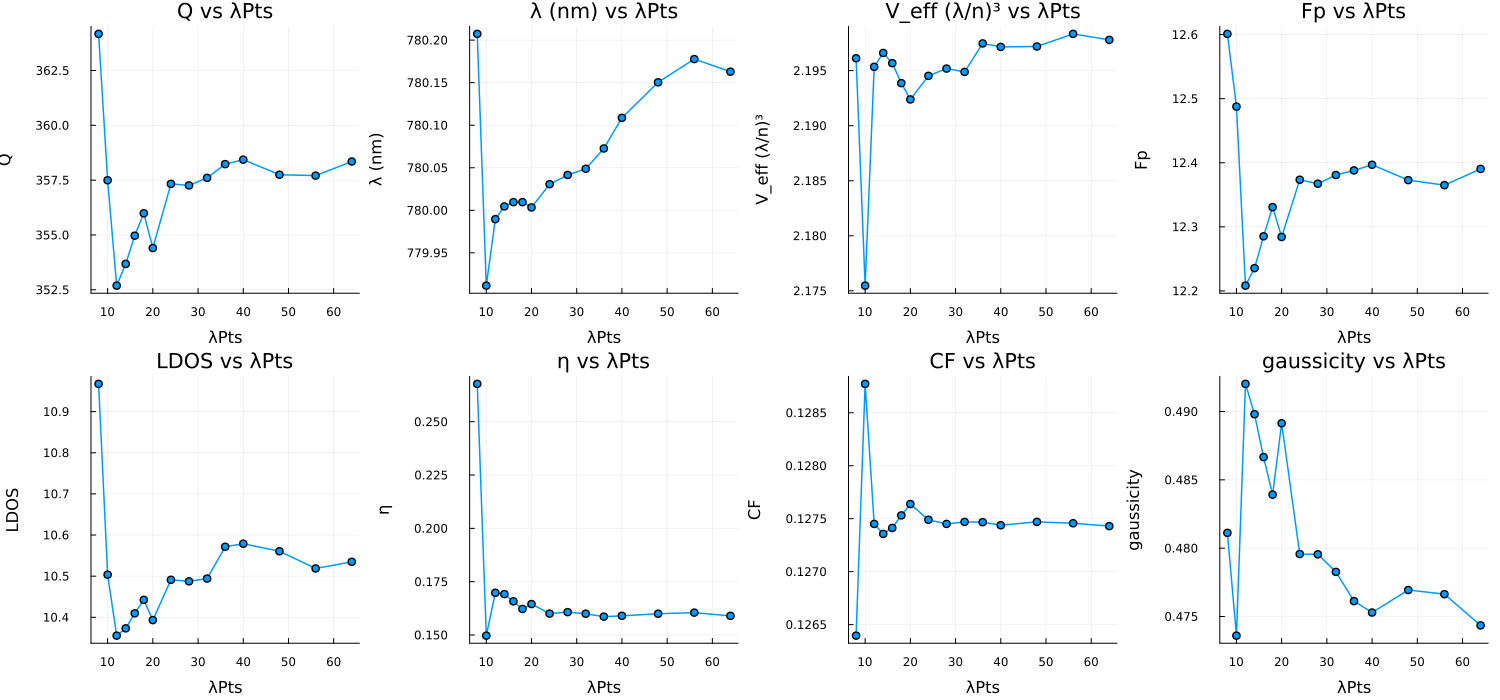

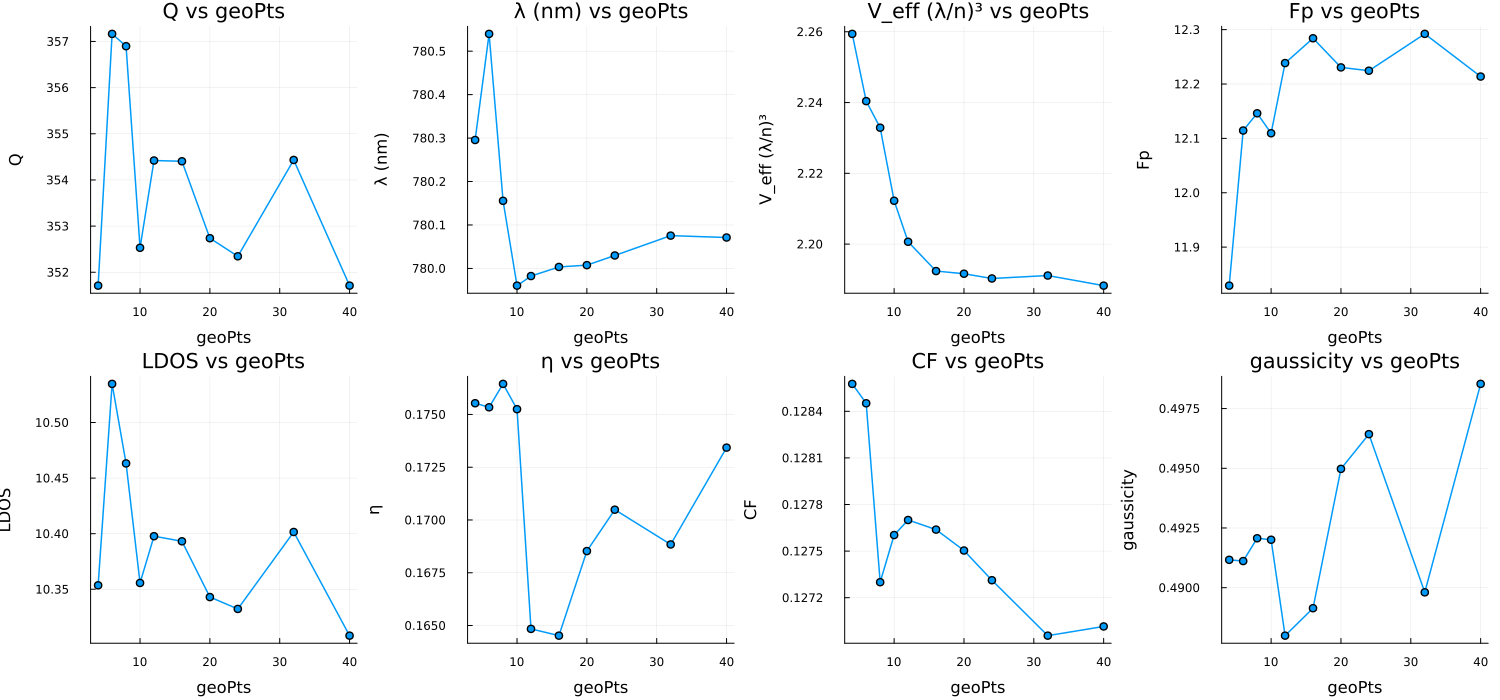

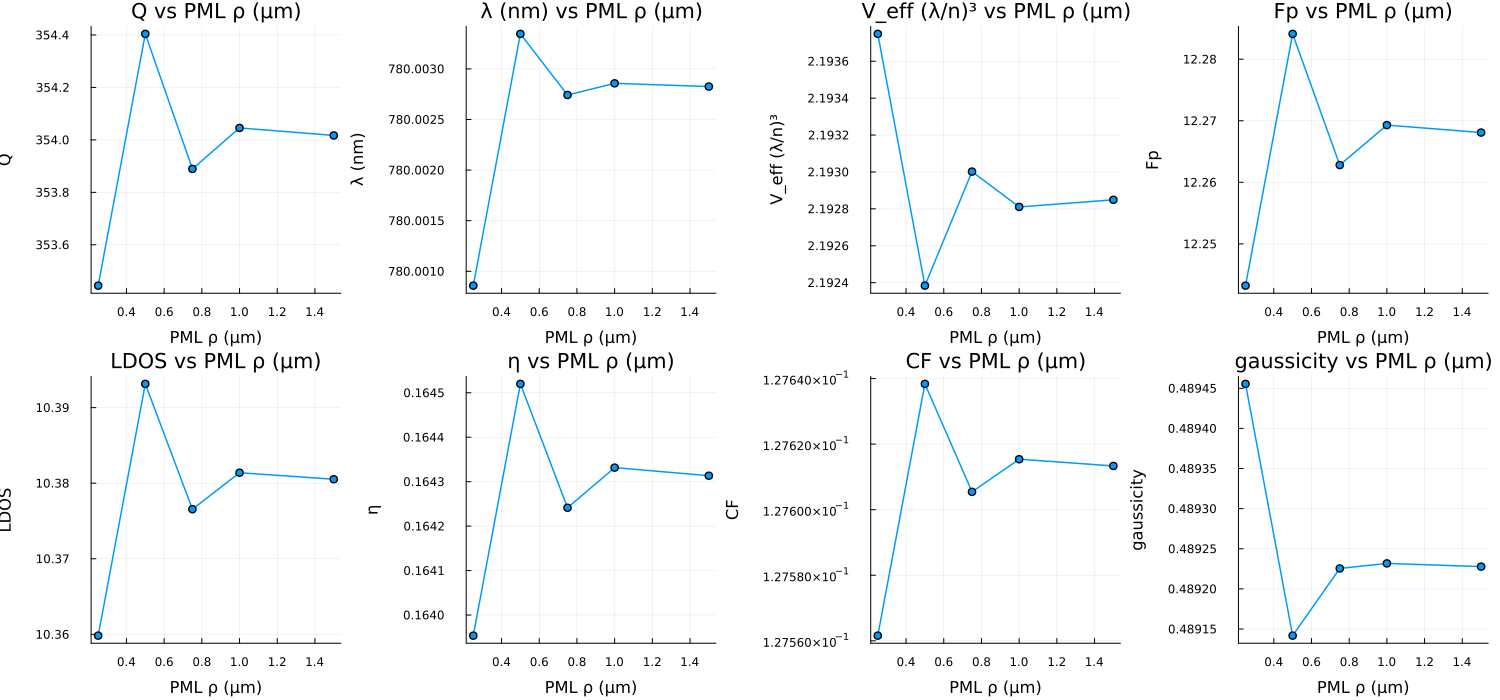

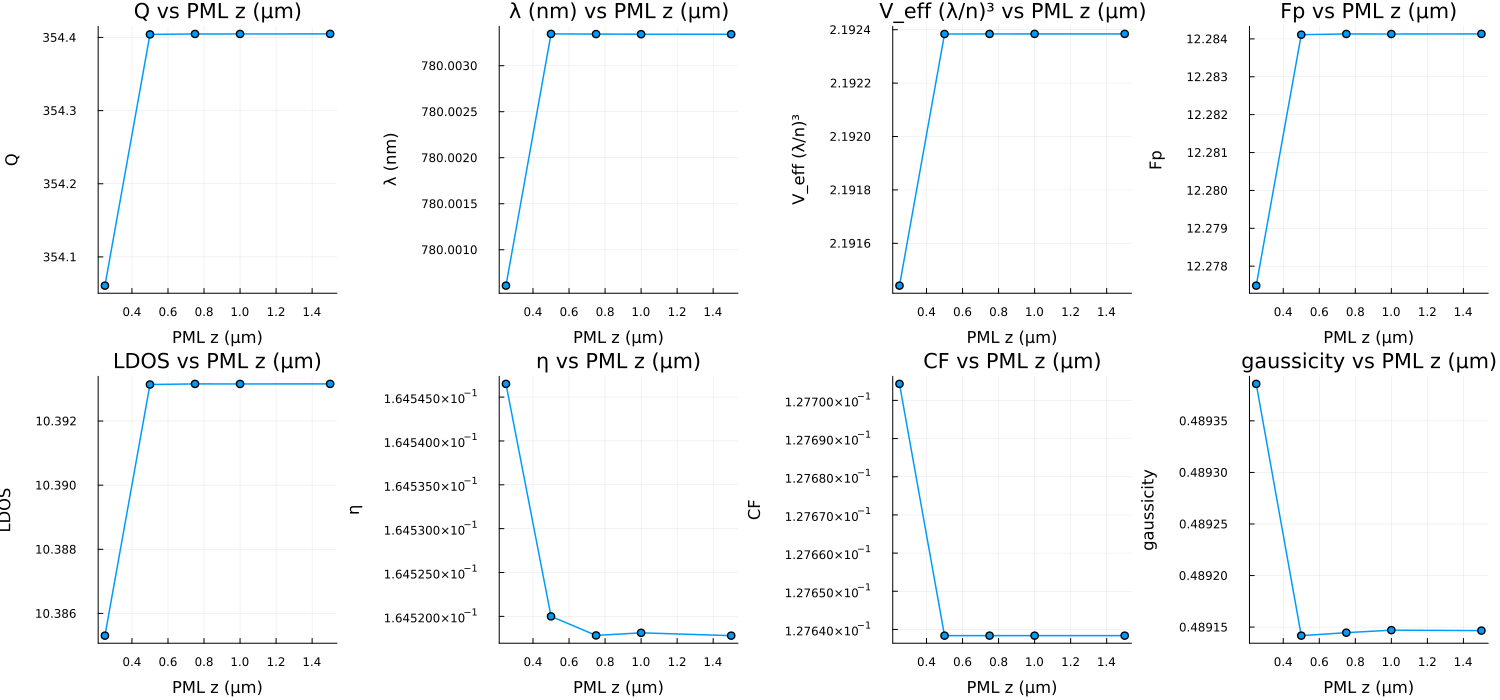

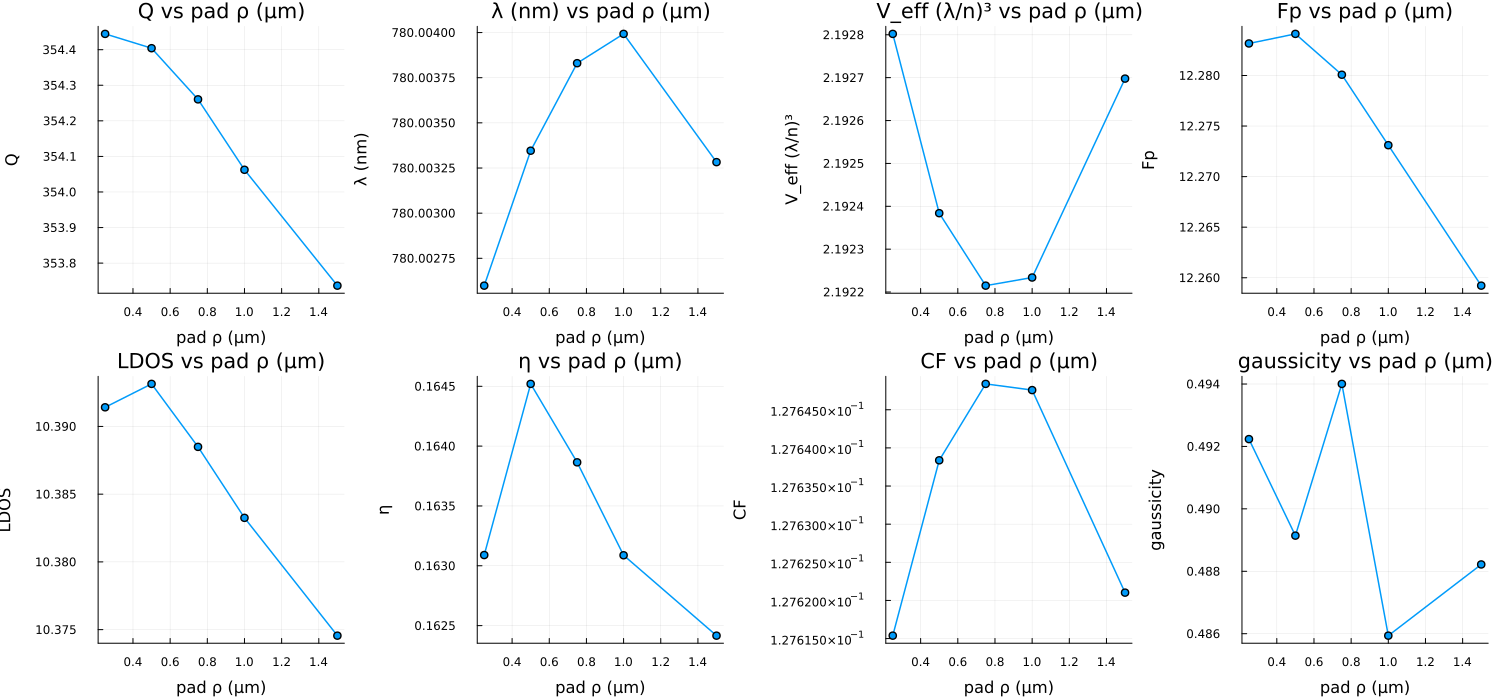

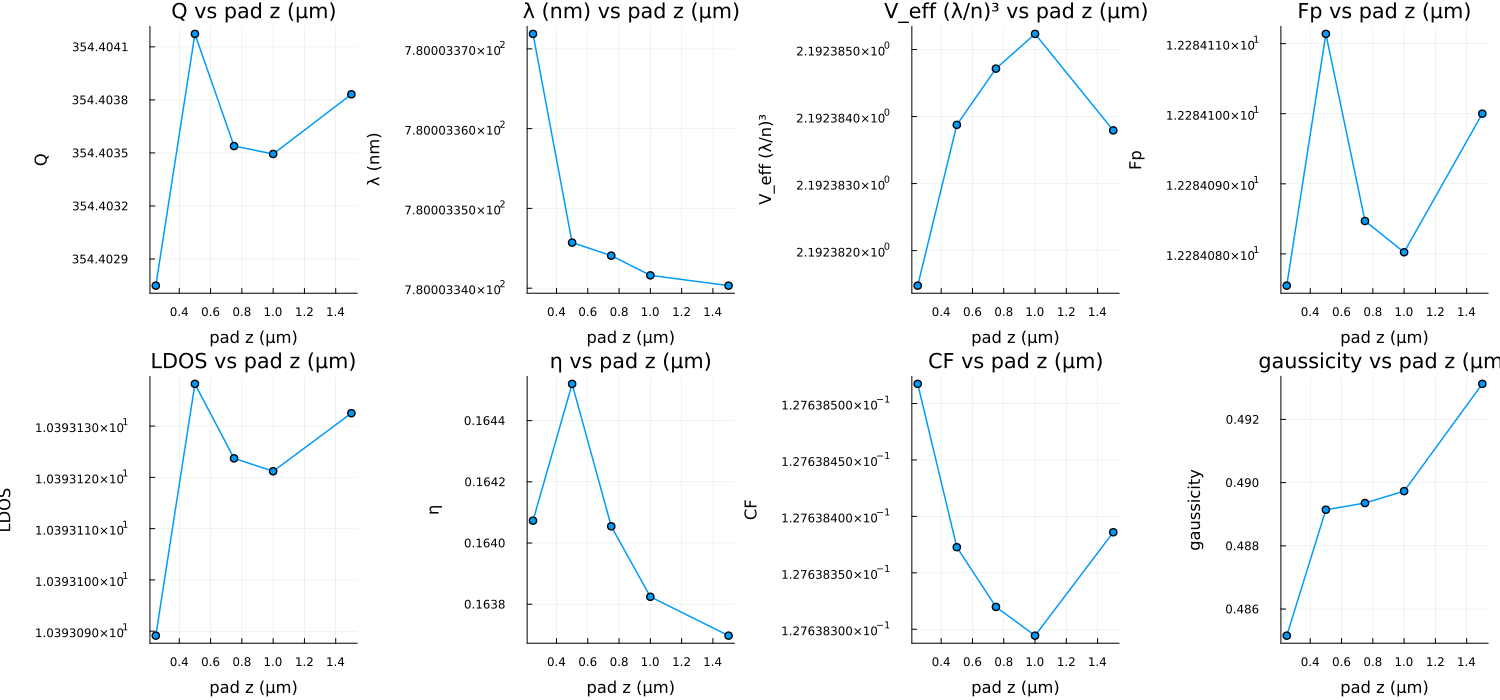

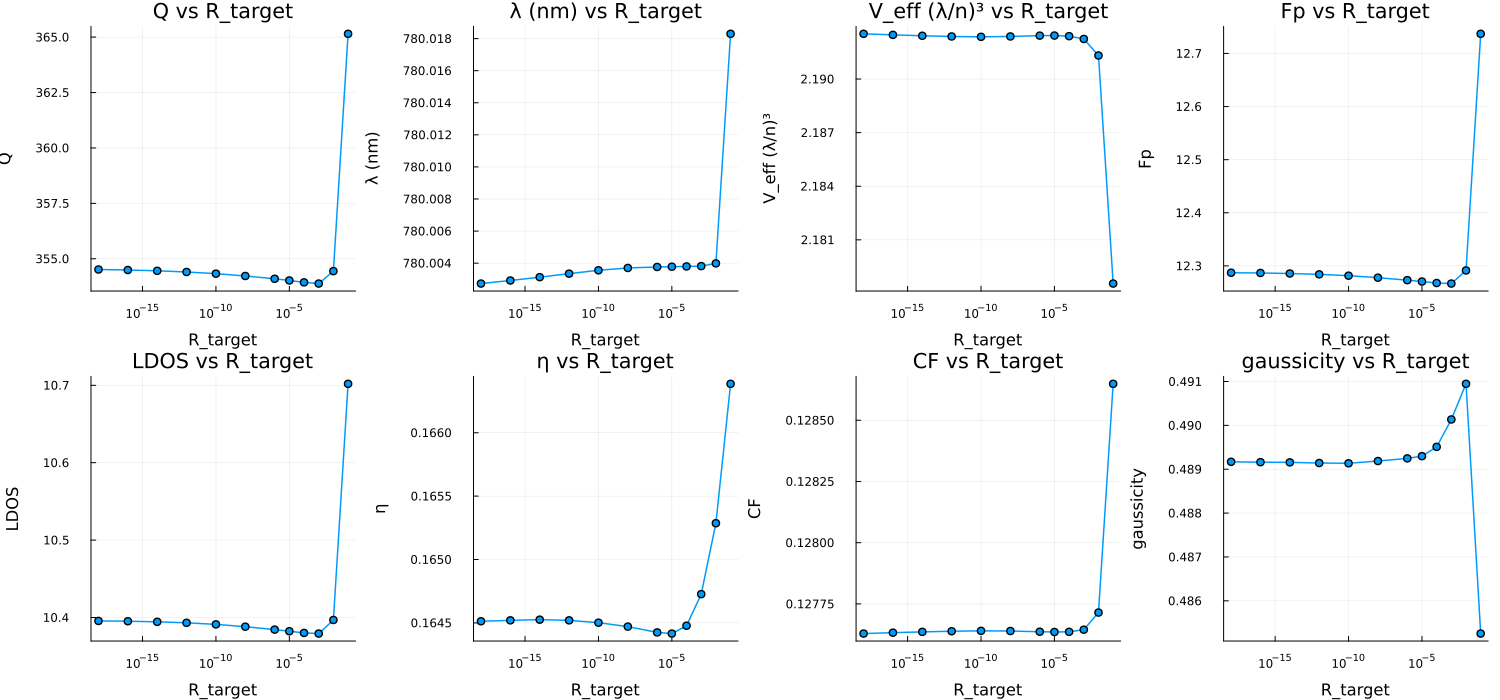

In [6]:
using Plots
gr(fmt = :png)

function plot_convergence(csv, xlabel; xscale=:identity)
    df = CSV.read(joinpath(resultsdir, csv), DataFrame)
    panels = [("Q",              :Q),
              ("λ (nm)",         :λ_nm),
              ("V_eff (λ/n)³",   :V),
              ("Fp",             :Fp),
              ("LDOS",           :Purcell),
              ("η",              :η),
              ("CF",             :CF),
              ("gaussicity",     :gaussicity)]
    plts = map(panels) do (ylabel, col)
        plot(df.value, df[!, col]; title="$ylabel vs $xlabel", xlabel, ylabel, xscale,
             marker=:circle, ms=4, lw=1.5, legend=false,
             left_margin=5Plots.mm, bottom_margin=5Plots.mm)
    end
    plot(plts...; layout=(2,4), size=(1500, 700))
end

for (csv, xl, xs) in [("convergence_lambdaPts.csv", "λPts",       :identity),
                      ("convergence_geoPts.csv",    "geoPts",     :identity),
                      ("convergence_PMLrho.csv",    "PML ρ (μm)", :identity),
                      ("convergence_PMLz.csv",      "PML z (μm)", :identity),
                      ("convergence_padrho.csv",    "pad ρ (μm)", :identity),
                      ("convergence_padz.csv",      "pad z (μm)", :identity),
                      ("convergence_Rtarget.csv",   "R_target",   :log10)]
    isfile(joinpath(resultsdir, csv)) || continue
    plt = plot_convergence(csv, xl; xscale=xs)
    savefig(plt, joinpath(resultsdir, replace(csv, ".csv" => ".png")))
    display(plt)
end

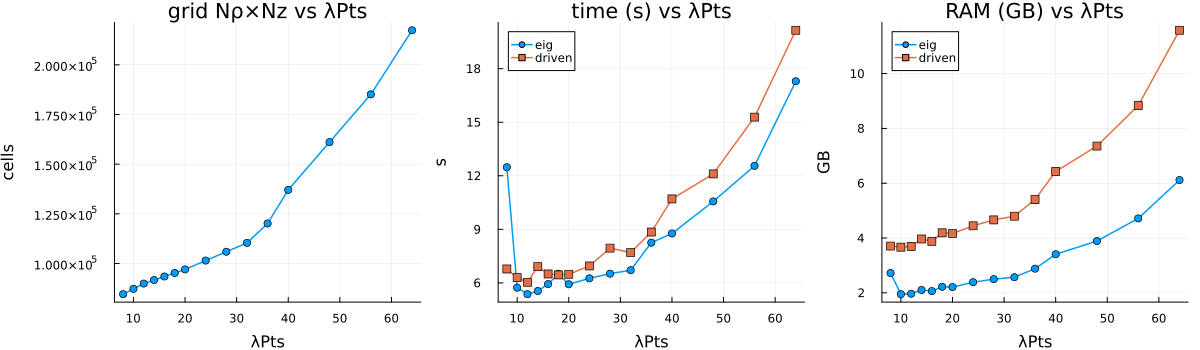

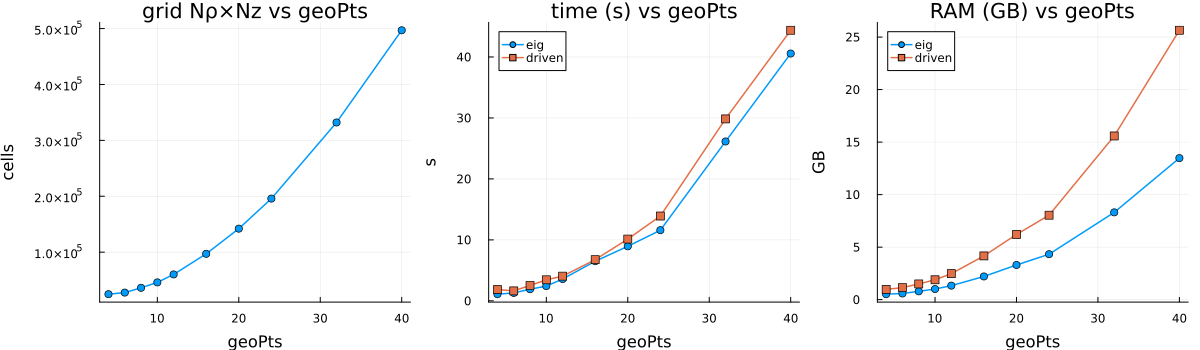

In [7]:
function plot_cost(csv, xlabel)
    df = CSV.read(joinpath(resultsdir, csv), DataFrame)
    p_grid = plot(df.value, df.Nρ .* df.Nz; title="grid Nρ×Nz vs $xlabel", xlabel, ylabel="cells",
                  marker=:circle, ms=4, lw=1.5, legend=false,
                  left_margin=5Plots.mm, bottom_margin=5Plots.mm)
    p_time = plot(df.value, df.eig_s; title="time (s) vs $xlabel", xlabel, ylabel="s",
                  marker=:circle, ms=4, lw=1.5, label="eig",
                  left_margin=5Plots.mm, bottom_margin=5Plots.mm)
    plot!(p_time, df.value, df.drv_s; marker=:square, ms=4, lw=1.5, label="driven")
    p_ram = plot(df.value, df.eig_GB; title="RAM (GB) vs $xlabel", xlabel, ylabel="GB",
                 marker=:circle, ms=4, lw=1.5, label="eig",
                 left_margin=5Plots.mm, bottom_margin=5Plots.mm)
    plot!(p_ram, df.value, df.drv_GB; marker=:square, ms=4, lw=1.5, label="driven")
    plot(p_grid, p_time, p_ram; layout=(1,3), size=(1200, 350))
end

for (csv, xl) in [("convergence_lambdaPts.csv", "λPts"),
                  ("convergence_geoPts.csv",    "geoPts")]
    isfile(joinpath(resultsdir, csv)) || continue
    plt = plot_cost(csv, xl)
    savefig(plt, joinpath(resultsdir, replace(csv, "convergence_" => "cost_", ".csv" => ".png")))
    display(plt)
end